Run PatchCore on texture datasets for unsupervised defect detection

In [1]:
# Install anomalib and other dependencies
!pip install anomalib
!pip install pytorch-lightning==2.3.0

import torch
import numpy as np
import matplotlib.pyplot as plt
from anomalib.data import MVTecAD
from anomalib.models import Patchcore
from anomalib.engine import Engine
# from anomalib.utils.visualization import get_visualization_image # Commented out due to ImportError

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 851.8/851.8 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.8/241.8 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 827.9/827.9 kB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 115.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 108.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 760.5/760.5 kB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 54.3 MB/s eta 0:00:00
  Created wheel for freia: filename=FrEIA-0.2-py3-none-any.whl size=42763 sha256=62d9b9e7182ec10d184f97a3f489fa72e0aca60da5145f2e5bdcd80839798e64
  Stored in 

In [2]:
from anomalib.data import MVTecAD
from torchvision import transforms
import anomalib
print(anomalib.__version__)
from google.colab import drive
drive.mount('/content/drive')

2.2.0
Mounted at /content/drive


In [3]:


import os
print(os.listdir("/content/drive/MyDrive/sampledatapatch"))

datamodule = MVTecAD(
    root="/content/drive/MyDrive/sampledatapatch",
    category="carpet"
)
datamodule.setup()


# Initialize the PatchCore model with a pre-trained WideResNet50 backbone.
model = Patchcore(
    backbone="wide_resnet50_2",
    layers=["layer2", "layer3"],
    coreset_sampling_ratio=0.1,
)
#
engine = Engine(
   # pixel_metrics=["pro", "aupro"],
   # image_metrics=["auroc", "f1_max"],
    accelerator="auto",
    devices=1,
)

# Fit the model (build the memory bank from normal images).
print("Building PatchCore memory bank...")
engine.fit(model=model, datamodule=datamodule)

# Test the model on the test set.
print("\nTesting model and evaluating metrics...")
test_results = engine.test(model=model, datamodule=datamodule)

['bottle', 'carpet']


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/276M [00:00<?, ?B/s]

INFO:lightning_fabric.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:lightning_fabric.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Building PatchCore memory bank...


...

Validation: |          | 0/? [00:00<?, ?it/s]



Selecting Coreset Indices.:   0%|          | 0/28672 [00:00<?, ?it/s]

Selecting Coreset Indices.:   0%|          | 1/28672 [00:00<1:08:28,  6.98it/s]

Selecting Coreset Indices.:   0%|          | 11/28672 [00:00<09:09, 52.19it/s] 

Selecting Coreset Indices.:   0%|          | 19/28672 [00:00<07:32, 63.35it/s]

Selecting Coreset Indices.:   0%|          | 34/28672 [00:00<05:07, 93.25it/s]

Selecting Coreset Indices.:   0%|          | 44/28672 [00:00<05:08, 92.71it/s]

Selecting Coreset Indices.:   0%|          | 58/28672 [00:00<04:29, 106.16it/s]

Selecting Coreset Indices.:   0%|          | 78/28672 [00:00<03:33, 133.82it/s]

Selecting Coreset Indices.:   0%|          | 99/28672 [00:00<03:02, 156.88it/s]

Selecting Coreset Indices.:   0%|          | 120/28672 [00:00<02:45, 172.24it/s]

Selecting Coreset Indices.:   0%|          | 141/28672 [00:01<02:36, 182.36it/s]

Selecting Coreset Indices.:   1%|          | 160/28672 [00:01<02:34, 184.00it/s]

Selecting Coreset Indices.:   1%|   


Testing model and evaluating metrics...


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        image_AUROC        │     0.986356258392334     │
│       image_F1Score       │    0.9717513918876648     │
│        pixel_AUROC        │    0.9908041954040527     │
│       pixel_F1Score       │    0.6074268817901611     │
└───────────────────────────┴───────────────────────────┘

In [4]:
print("\n--- Performance Evaluation Metrics ---")

test_results_dict = test_results[0]
for metric_name, value in test_results_dict.items():
    if "auroc" in metric_name or "pro" in metric_name or "f1" in metric_name:
        print(f"{metric_name}: {value:.4f}")

print(type(test_results))
print(test_results)

"""for metric_name, value in test_results.items():
    if "auroc" in metric_name or "pro" in metric_name or "f1" in metric_name:
        print(f"{metric_name}: {value:.4f}")"""


--- Performance Evaluation Metrics ---
<class 'list'>
[{'image_AUROC': 0.986356258392334, 'image_F1Score': 0.9717513918876648, 'pixel_AUROC': 0.9908041954040527, 'pixel_F1Score': 0.6074268817901611}]


'for metric_name, value in test_results.items():\n    if "auroc" in metric_name or "pro" in metric_name or "f1" in metric_name:\n        print(f"{metric_name}: {value:.4f}")'

INFO:lightning_fabric.utilities.rank_zero:The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Running prediction using Engine...


Predicting: |          | 0/? [00:00<?, ?it/s]

Type of prediction_results: <class 'list'>
Prediction keys: ['image', 'gt_label', 'gt_mask', 'mask_path', 'anomaly_map', 'pred_score', 'pred_mask', 'pred_label', 'explanation', 'image_path']


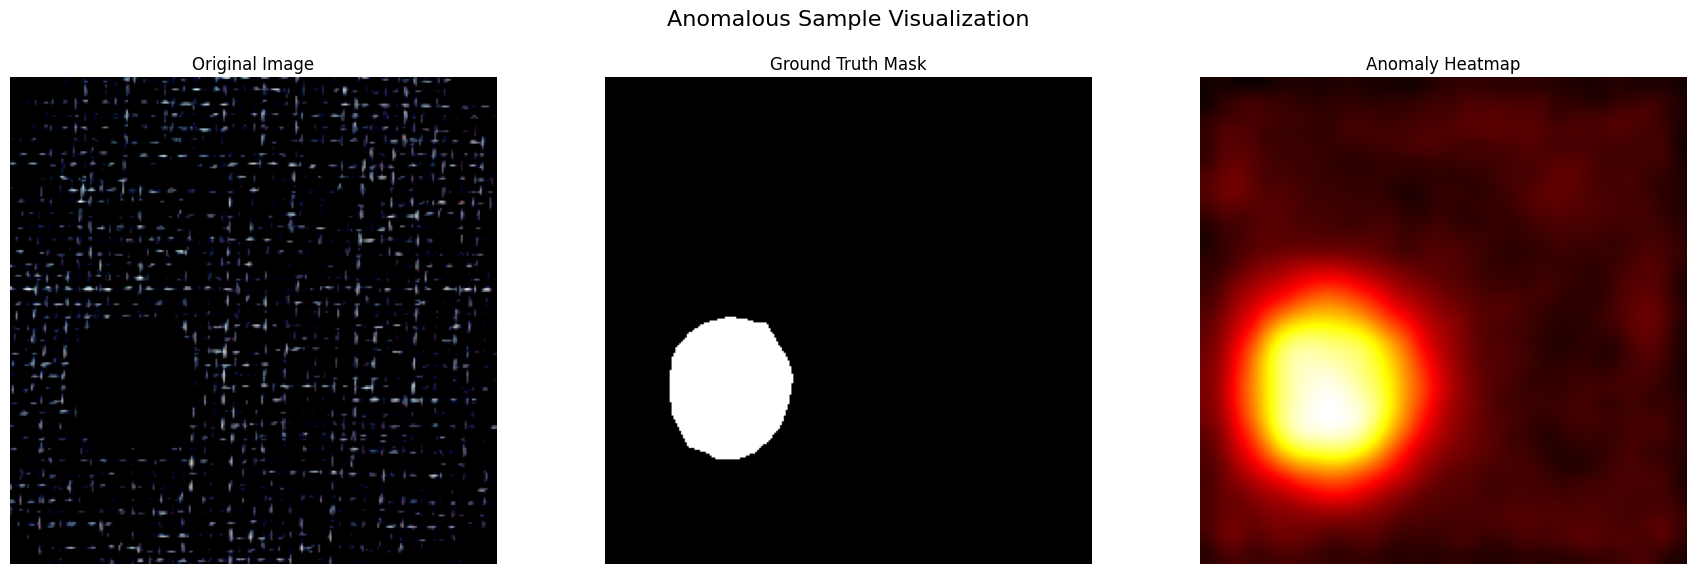

No normal samples found.


In [5]:
# Create a test dataloader to get some sample images
test_dataloader = datamodule.test_dataloader()
sample_batch = next(iter(test_dataloader))

# Move tensors to device safely depending on batch type
if isinstance(sample_batch, dict):
    sample_batch = {
        k: (v.to(device) if hasattr(v, "to") else v)
        for k, v in sample_batch.items()
    }
elif isinstance(sample_batch, (list, tuple)):
    sample_batch = [
        x.to(device) if hasattr(x, "to") else x
        for x in sample_batch
    ]
else:
    # Single tensor batch
    if hasattr(sample_batch, "to"):
        sample_batch = sample_batch.to(device)

print("\nRunning prediction using Engine...")
prediction_results = engine.predict(model=model, datamodule=datamodule)

print("Type of prediction_results:", type(prediction_results))

#first batch output
predictions = prediction_results[0]

print("Prediction keys:", predictions.keys())

anomalous_indices = (predictions.pred_label == 1).nonzero(as_tuple=True)[0]
normal_indices = (predictions.pred_label == 0).nonzero(as_tuple=True)[0]


# Visualization function
def display_results(predictions, image_index, title):
    image = predictions.image[image_index]
    anomaly_map = predictions.anomaly_map[image_index]

    gt_mask = predictions.gt_mask if hasattr(predictions, "gt_mask") else None

    fig, ax = plt.subplots(1, 3, figsize=(18, 6))

    # Original image
    ax[0].imshow(image.permute(1, 2, 0).cpu().numpy())
    ax[0].set_title("Original Image")
    ax[0].axis("off")

    # Ground truth mask
    if gt_mask is not None:
        mask = gt_mask[image_index]
        ax[1].imshow(mask.squeeze().cpu().numpy(), cmap="gray")
        ax[1].set_title("Ground Truth Mask")
    else:
        ax[1].text(0.5, 0.5, "No GT Mask", ha="center", va="center")
        ax[1].set_title("Ground Truth Mask")
    ax[1].axis("off")

    # Anomaly heatmap
    ax[2].imshow(anomaly_map.squeeze().cpu().numpy(), cmap="hot")
    ax[2].set_title("Anomaly Heatmap")
    ax[2].axis("off")

    fig.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


# Show anomalous sample
if anomalous_indices.numel() > 0:
    display_results(predictions, anomalous_indices[0], "Anomalous Sample Visualization")
else:
    print("No anomalous samples found.")

# Show normal sample
if normal_indices.numel() > 0:
    display_results(predictions, normal_indices[0], "Normal Sample Visualization")
else:
    print("No normal samples found.")

